<a href="https://colab.research.google.com/github/AsimaZaheer/Data-Classification-Using-AI/blob/main/Data%20Classification%20Using%20AI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [40]:
import pandas as pd
import numpy as np

from sklearn.datasets import load_iris
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [41]:
iris = load_iris()
print(iris)

{'data': array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
     

In [42]:
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df.head()
print("Shape of Dataset:", df.shape)
print(df.isnull().sum())
df.describe()
print(df.isnull().sum())

Shape of Dataset: (150, 4)
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
dtype: int64
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
dtype: int64


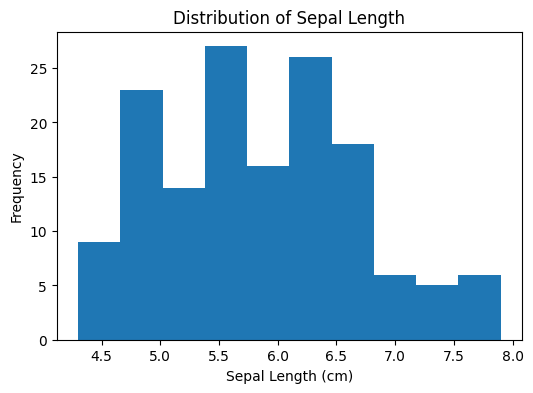

In [43]:
plt.figure(figsize=(6,4))
plt.hist(df["sepal length (cm)"], bins=10)
plt.title("Distribution of Sepal Length")
plt.xlabel("Sepal Length (cm)")
plt.ylabel("Frequency")
plt.show()

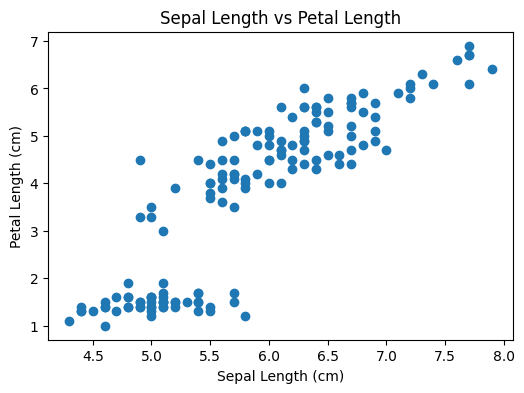

In [44]:
plt.figure(figsize=(6,4))
plt.scatter(
    df["sepal length (cm)"],
    df["petal length (cm)"]
)
plt.title("Sepal Length vs Petal Length")
plt.xlabel("Sepal Length (cm)")
plt.ylabel("Petal Length (cm)")
plt.show()

In [45]:
X = df
y = iris.target
print(X.head())
print(y[:10])
print(iris.target_names)

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2
[0 0 0 0 0 0 0 0 0 0]
['setosa' 'versicolor' 'virginica']


In [46]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [47]:
print("Training Features:", X_train.shape)
print("Testing Features :", X_test.shape)

print("Training Labels  :", y_train.shape)
print("Testing Labels   :", y_test.shape)

Training Features: (120, 4)
Testing Features : (30, 4)
Training Labels  : (120,)
Testing Labels   : (30,)


In [48]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
print(X_train[:5])
model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train, y_train)
print(model)

[[-1.47393679  1.20365799 -1.56253475 -1.31260282]
 [-0.13307079  2.99237573 -1.27600637 -1.04563275]
 [ 1.08589829  0.08570939  0.38585821  0.28921757]
 [-1.23014297  0.75647855 -1.2187007  -1.31260282]
 [-1.7177306   0.30929911 -1.39061772 -1.31260282]]
KNeighborsClassifier()


In [49]:
y_pred = model.predict(X_test)
print("Predicted Values:")
print(y_pred[:10])
print("Actual Values:")
print(y_test[:10])
comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

comparison.head(10)

Predicted Values:
[1 0 2 1 1 0 1 2 1 1]
Actual Values:
[1 0 2 1 1 0 1 2 1 1]


,Actual,Predicted
0,1,1
1,0,0
2,2,2
3,1,1
4,1,1
5,0,0
6,1,1
7,2,2
8,1,1
9,1,1


In [50]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy*100:.2f}%")
cm = confusion_matrix(y_test, y_pred)
print(cm)
print(classification_report(
    y_test,
    y_pred,
    target_names=iris.target_names
))

Accuracy: 100.00%
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [51]:
print("\n========== Predict Your Own Iris Flower ==========")

sepal_length = float(input("Enter Sepal Length (cm): "))
sepal_width = float(input("Enter Sepal Width (cm): "))
petal_length = float(input("Enter Petal Length (cm): "))
petal_width = float(input("Enter Petal Width (cm): "))


========== Predict Your Own Iris Flower ==========
Enter Sepal Length (cm): 1.3
Enter Sepal Width (cm): 5.6
Enter Petal Length (cm): 3.2
Enter Petal Width (cm): 2.1


In [52]:
new_flower = pd.DataFrame(
    [[
        sepal_length,
        sepal_width,
        petal_length,
        petal_width
    ]],
    columns=df.columns
)

new_flower = scaler.transform(new_flower)
prediction = model.predict(new_flower)
print("\n🌸 Predicted Flower Species:", iris.target_names[prediction][0])


🌸 Predicted Flower Species: setosa
